# Lab 25 — Ethics, Bias, and Mathematical Responsibility

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wanghemath/Book-MathNLP/blob/main/labs/chapter-25-ethics-bias-responsibility.ipynb)

**Book:** *The Mathematics of Natural Language Processing*  
**Chapter:** 25 — Ethics, Bias, and Mathematical Responsibility  
**Repository:** https://github.com/wanghemath/Book-MathNLP

This lab is designed for independent study. It explains the needed background before each programming section and uses small synthetic NLP-style examples so that every calculation is transparent.

## What you will learn

By the end of this lab, you should be able to:

1. represent a responsible NLP audit using random variables $X$, $Y$, $A$, model scores $S$, and decisions $\widehat{Y}$;
2. compute group-wise confusion matrices and fairness metrics from scratch;
3. explain why threshold choice can improve one metric while worsening another;
4. estimate calibration and expected calibration error;
5. study uncertainty with bootstrap intervals;
6. simulate distribution shift and importance weighting;
7. audit toy embedding associations and understand projection-based correction;
8. implement selective prediction and abstention;
9. connect privacy, factuality, and RAG-style deployment to mathematical responsibility.

> The goal of this lab is not to reduce ethics to formulas. The goal is to use mathematics to make assumptions visible.

## 1. Mathematical setup

A responsible NLP system begins with a statistical description.

- $X$: input text, document, prompt, query, or conversation.
- $Y$: target variable, such as a class label, relevance label, toxicity label, or answer-quality label.
- $A$: an auditing variable, such as source, text genre, language variety, institution type, or another context variable.
- $S \in [0,1]$: model score.
- $\widehat{Y} = 1\{S \ge t\}$: deployed decision after choosing a threshold $t$.

A performance metric is a statistic computed under assumptions. It is not an ethical conclusion by itself.

In this lab we use synthetic data with two text sources:

- `formal_helpdesk`: formal policy/support messages;
- `informal_forum`: informal question/forum messages.

The group variable is intentionally a **context/source variable**, not a demographic identity. The mathematics is the same, but this avoids making claims about real people from artificial data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

rng = np.random.default_rng(7243)

## 2. Create a synthetic NLP-style audit dataset

We simulate a binary NLP decision task: decide whether a short text should be sent for human review.

The label is:

$$
Y =
\begin{cases}
1, & \text{text truly needs human review},\\
0, & \text{text does not need human review}.
\end{cases}
$$

The model score $S$ is not perfect. It is intentionally a little weaker on the informal source. This lets us study group-wise performance differences.

In [2]:
def make_synthetic_audit_data(n_per_group=500, seed=7243):
    rng = np.random.default_rng(seed)

    risk_words = ["urgent", "unsafe", "private", "violation", "appeal", "blocked"]
    safe_words = ["summary", "question", "draft", "example", "general", "resource"]
    formal_words = ["please", "policy", "document", "request", "review", "procedure"]
    informal_words = ["pls", "idk", "quick", "lol", "u", "thread"]

    rows = []
    specs = [
        ("formal_helpdesk", 0.42, 0.00),     # group, base rate, score shift
        ("informal_forum", 0.30, -0.08),     # lower scores for positive examples on average
    ]

    for group, base_rate, score_shift in specs:
        for i in range(n_per_group):
            y = rng.binomial(1, base_rate)
            content = rng.choice(risk_words if y == 1 else safe_words, size=3, replace=True).tolist()
            style = rng.choice(formal_words if group == "formal_helpdesk" else informal_words, size=3, replace=True).tolist()
            tokens = content + style
            rng.shuffle(tokens)
            text = " ".join(tokens)

            # Score is correlated with y, but group/source shifts and noise affect it.
            mean = 0.70 if y == 1 else 0.30
            noise = rng.normal(0, 0.15)
            score = np.clip(mean + score_shift * y + 0.03 * (group == "informal_forum") + noise, 0.01, 0.99)
            rows.append({"group": group, "text": text, "y": y, "score": score})

    return pd.DataFrame(rows)

scores = make_synthetic_audit_data()
scores.head()

,group,text,y,score
0,formal_helpdesk,request please question draft document example,0,0.202708
1,formal_helpdesk,request request private violation blocked policy,1,0.675099
2,formal_helpdesk,request general procedure general resource policy,0,0.167877
3,formal_helpdesk,violation please violation review private docu...,1,0.654989
4,formal_helpdesk,unsafe urgent document please review urgent,1,0.644152


In [3]:
scores.groupby("group").agg(
    n=("y", "size"),
    base_rate=("y", "mean"),
    mean_score=("score", "mean"),
    mean_score_positive=("score", lambda s: scores.loc[s.index][scores.loc[s.index, "y"] == 1]["score"].mean()),
    mean_score_negative=("score", lambda s: scores.loc[s.index][scores.loc[s.index, "y"] == 0]["score"].mean()),
)

,n,base_rate,mean_score,mean_score_positive,mean_score_negative
group,,,,,
formal_helpdesk,500,0.410,0.461916,0.707421,0.291310
informal_forum,500,0.298,0.431015,0.660652,0.333534


### Plot the score distributions

A threshold $t$ turns scores into decisions. Before computing fairness metrics, inspect the score distributions. Differences in score distribution can lead to differences in TPR, FPR, precision, and selection rate.

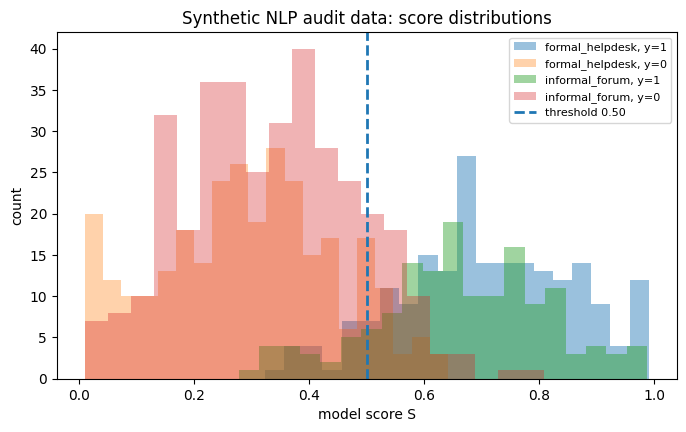

In [4]:
plt.figure(figsize=(8, 4.5))
for group, sub in scores.groupby("group"):
    plt.hist(sub.loc[sub["y"] == 1, "score"], bins=20, alpha=0.45, label=f"{group}, y=1")
    plt.hist(sub.loc[sub["y"] == 0, "score"], bins=20, alpha=0.35, label=f"{group}, y=0")
plt.axvline(0.50, linestyle="--", linewidth=2, label="threshold 0.50")
plt.xlabel("model score S")
plt.ylabel("count")
plt.title("Synthetic NLP audit data: score distributions")
plt.legend(fontsize=8)
plt.show()

## 3. Confusion matrices and group fairness metrics

For a fixed group $a$, define:

$$
\mathrm{TPR}_a = P(\widehat{Y}=1 \mid Y=1,A=a),
$$

$$
\mathrm{FPR}_a = P(\widehat{Y}=1 \mid Y=0,A=a),
$$

$$
\mathrm{PPV}_a = P(Y=1 \mid \widehat{Y}=1,A=a),
$$

$$
\mathrm{SR}_a = P(\widehat{Y}=1 \mid A=a).
$$

Names:

- TPR: true positive rate, also recall or sensitivity.
- FPR: false positive rate.
- PPV: positive predictive value, also precision.
- SR: selection rate.

Common fairness criteria compare these quantities across groups. For example, equal opportunity asks for similar TPR values across groups; equalized odds asks for similar TPR and FPR values.

In [5]:
def safe_div(num, den):
    return num / den if den != 0 else np.nan


def group_confusion_metrics(df, threshold=0.50, score_col="score", label_col="y", group_col="group"):
    rows = []
    for group, sub in df.groupby(group_col):
        y = sub[label_col].to_numpy().astype(int)
        yhat = (sub[score_col].to_numpy() >= threshold).astype(int)

        tp = int(((yhat == 1) & (y == 1)).sum())
        fp = int(((yhat == 1) & (y == 0)).sum())
        fn = int(((yhat == 0) & (y == 1)).sum())
        tn = int(((yhat == 0) & (y == 0)).sum())
        n = len(sub)

        rows.append({
            "group": group,
            "n": n,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn,
            "base_rate": y.mean(),
            "selection_rate": yhat.mean(),
            "accuracy": (tp + tn) / n,
            "TPR": safe_div(tp, tp + fn),
            "FPR": safe_div(fp, fp + tn),
            "PPV": safe_div(tp, tp + fp),
            "FNR": safe_div(fn, tp + fn),
            "NPV": safe_div(tn, tn + fn),
        })
    return pd.DataFrame(rows)

report_050 = group_confusion_metrics(scores, threshold=0.50)
report_050

,group,n,TP,FP,FN,TN,base_rate,selection_rate,accuracy,TPR,FPR,PPV,FNR,NPV
0,formal_helpdesk,500,184,28,21,267,0.410,0.424,0.902,0.897561,0.094915,0.867925,0.102439,0.927083
1,informal_forum,500,129,51,20,300,0.298,0.360,0.858,0.865772,0.145299,0.716667,0.134228,0.937500


In [6]:
def fairness_gap_table(report):
    metrics = ["selection_rate", "accuracy", "TPR", "FPR", "PPV", "FNR"]
    rows = []
    for metric in metrics:
        values = report[metric].dropna()
        rows.append({
            "metric": metric,
            "min": values.min(),
            "max": values.max(),
            "absolute_gap": values.max() - values.min()
        })
    return pd.DataFrame(rows)

fairness_gap_table(report_050)

,metric,min,max,absolute_gap
0,selection_rate,0.360000,0.424000,0.064000
1,accuracy,0.858000,0.902000,0.044000
2,TPR,0.865772,0.897561,0.031789
3,FPR,0.094915,0.145299,0.050384
4,PPV,0.716667,0.867925,0.151258
5,FNR,0.102439,0.134228,0.031789


### Interpretation prompt

Look at the group-wise report.

- Which group has higher TPR?
- Which group has higher FPR?
- Are the base rates equal?
- Is the selection-rate gap the same as the TPR gap?

A responsible audit does not stop at one number. It asks which metric is appropriate for the decision and what uncertainty is attached to that metric.

## 4. Threshold scanning: one threshold, many tradeoffs

The deployed decision is

$$
\widehat{Y}=1\{S \ge t\}.
$$

Changing $t$ changes all metrics. A threshold that maximizes average accuracy may not minimize TPR gap or FPR gap.

In [7]:
def threshold_scan(df, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 91)
    rows = []
    for t in thresholds:
        rep = group_confusion_metrics(df, threshold=t).set_index("group")
        gaps = fairness_gap_table(rep.reset_index()).set_index("metric")
        rows.append({
            "threshold": t,
            "overall_accuracy": ((df["score"] >= t).astype(int).to_numpy() == df["y"].to_numpy()).mean(),
            "mean_group_accuracy": rep["accuracy"].mean(),
            "TPR_gap": gaps.loc["TPR", "absolute_gap"],
            "FPR_gap": gaps.loc["FPR", "absolute_gap"],
            "PPV_gap": gaps.loc["PPV", "absolute_gap"],
            "selection_gap": gaps.loc["selection_rate", "absolute_gap"],
        })
    return pd.DataFrame(rows)

scan = threshold_scan(scores)
scan.head()

,threshold,overall_accuracy,mean_group_accuracy,TPR_gap,FPR_gap,PPV_gap,selection_gap
0,0.05,0.384,0.384,0.0,0.058023,0.127538,0.032
1,0.06,0.389,0.389,0.0,0.068733,0.130558,0.038
2,0.07,0.395,0.395,0.0,0.070356,0.131467,0.038
3,0.08,0.403,0.403,0.0,0.084997,0.135856,0.046
4,0.09,0.409,0.409,0.0,0.092858,0.138436,0.050


In [8]:
best_accuracy = scan.sort_values("overall_accuracy", ascending=False).head(5)
best_tpr_gap = scan.sort_values("TPR_gap", ascending=True).head(5)
best_fpr_gap = scan.sort_values("FPR_gap", ascending=True).head(5)

print("Best thresholds by overall accuracy:")
display(best_accuracy)
print("Best thresholds by TPR gap:")
display(best_tpr_gap)
print("Best thresholds by FPR gap:")
display(best_fpr_gap)

Best thresholds by overall accuracy:


,threshold,overall_accuracy,mean_group_accuracy,TPR_gap,FPR_gap,PPV_gap,selection_gap
49,0.54,0.899,0.899,0.058046,0.044251,0.136877,0.078
52,0.57,0.898,0.898,0.039777,0.020774,0.084639,0.084
48,0.53,0.898,0.898,0.057423,0.048327,0.145197,0.076
53,0.58,0.898,0.898,0.055034,0.015616,0.072536,0.092
50,0.55,0.897,0.897,0.063546,0.045333,0.139171,0.078


Best thresholds by TPR gap:


,threshold,overall_accuracy,mean_group_accuracy,TPR_gap,FPR_gap,PPV_gap,selection_gap
0,0.05,0.384,0.384,0.0,0.058023,0.127538,0.032
1,0.06,0.389,0.389,0.0,0.068733,0.130558,0.038
2,0.07,0.395,0.395,0.0,0.070356,0.131467,0.038
3,0.08,0.403,0.403,0.0,0.084997,0.135856,0.046
4,0.09,0.409,0.409,0.0,0.092858,0.138436,0.050


Best thresholds by FPR gap:


,threshold,overall_accuracy,mean_group_accuracy,TPR_gap,FPR_gap,PPV_gap,selection_gap
88,0.93,0.667,0.667,0.032902,0.0,0.0,0.018
80,0.85,0.705,0.705,0.125552,0.0,0.0,0.062
82,0.87,0.690,0.690,0.087150,0.0,0.0,0.044
81,0.86,0.697,0.697,0.109707,0.0,0.0,0.054
84,0.89,0.682,0.682,0.048126,0.0,0.0,0.028


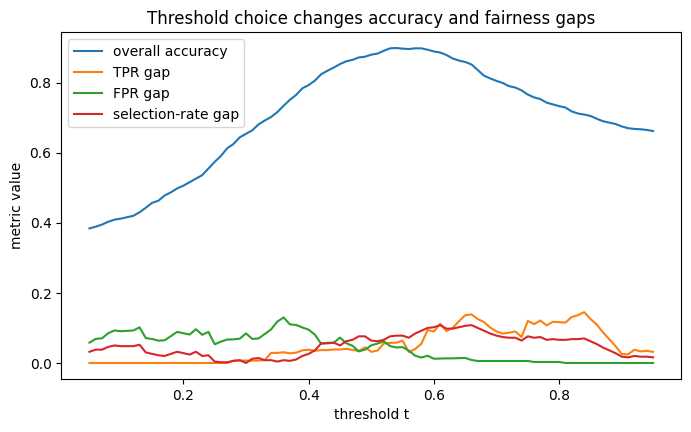

In [9]:
plt.figure(figsize=(8, 4.5))
plt.plot(scan["threshold"], scan["overall_accuracy"], label="overall accuracy")
plt.plot(scan["threshold"], scan["TPR_gap"], label="TPR gap")
plt.plot(scan["threshold"], scan["FPR_gap"], label="FPR gap")
plt.plot(scan["threshold"], scan["selection_gap"], label="selection-rate gap")
plt.xlabel("threshold t")
plt.ylabel("metric value")
plt.title("Threshold choice changes accuracy and fairness gaps")
plt.legend()
plt.show()

### Checkpoint

The plot should make the central lesson visible: there is no single mathematical threshold that is automatically “ethical.” Threshold choice is a design decision. It should be connected to the application, the meaning of false positives and false negatives, and the availability of review or appeal.

## 5. Bootstrap uncertainty for subgroup metrics

Group metrics are estimates from finite samples. A small subgroup can have a large apparent fairness gap simply because of sampling variation.

A simple bootstrap procedure:

1. resample rows with replacement within each group;
2. recompute a metric;
3. repeat many times;
4. report percentiles of the bootstrap distribution.

This is not a full causal analysis, but it is a useful uncertainty diagnostic.

In [10]:
def bootstrap_metric_intervals(df, threshold=0.50, B=300, seed=123):
    rng = np.random.default_rng(seed)
    groups = sorted(df["group"].unique())
    rows = []
    for group in groups:
        sub = df[df["group"] == group].reset_index(drop=True)
        estimates = {"TPR": [], "FPR": [], "PPV": [], "selection_rate": [], "accuracy": []}
        n = len(sub)
        for _ in range(B):
            idx = rng.integers(0, n, size=n)
            boot = sub.iloc[idx]
            rep = group_confusion_metrics(boot, threshold=threshold).iloc[0]
            for m in estimates:
                estimates[m].append(rep[m])
        for m, vals in estimates.items():
            vals = np.asarray(vals, dtype=float)
            rows.append({
                "group": group,
                "metric": m,
                "estimate": group_confusion_metrics(sub, threshold=threshold).iloc[0][m],
                "ci_low": np.nanpercentile(vals, 2.5),
                "ci_high": np.nanpercentile(vals, 97.5),
            })
    return pd.DataFrame(rows)

boot = bootstrap_metric_intervals(scores, threshold=0.50, B=300)
boot.head(10)

,group,metric,estimate,ci_low,ci_high
0,formal_helpdesk,TPR,0.897561,0.859157,0.937657
1,formal_helpdesk,FPR,0.094915,0.062386,0.130071
2,formal_helpdesk,PPV,0.867925,0.822787,0.910851
3,formal_helpdesk,selection_rate,0.424000,0.384000,0.468000
4,formal_helpdesk,accuracy,0.902000,0.876950,0.928000
5,informal_forum,TPR,0.865772,0.808855,0.916411
6,informal_forum,FPR,0.145299,0.113342,0.183529
7,informal_forum,PPV,0.716667,0.643464,0.775905
8,informal_forum,selection_rate,0.360000,0.322000,0.404000
9,informal_forum,accuracy,0.858000,0.828000,0.886100


In [11]:
boot[boot["metric"].isin(["TPR", "FPR", "selection_rate", "accuracy"])]

,group,metric,estimate,ci_low,ci_high
0,formal_helpdesk,TPR,0.897561,0.859157,0.937657
1,formal_helpdesk,FPR,0.094915,0.062386,0.130071
3,formal_helpdesk,selection_rate,0.424000,0.384000,0.468000
4,formal_helpdesk,accuracy,0.902000,0.876950,0.928000
5,informal_forum,TPR,0.865772,0.808855,0.916411
6,informal_forum,FPR,0.145299,0.113342,0.183529
8,informal_forum,selection_rate,0.360000,0.322000,0.404000
9,informal_forum,accuracy,0.858000,0.828000,0.886100


## 6. Calibration and expected calibration error

A score $S$ is calibrated if

$$
P(Y=1\mid S=s)=s.
$$

In practice we bin scores. For bin $B_m$,

$$
\operatorname{acc}(B_m)=\frac{1}{|B_m|}\sum_{i\in B_m} y_i,
\qquad
\operatorname{conf}(B_m)=\frac{1}{|B_m|}\sum_{i\in B_m} s_i.
$$

The expected calibration error is approximated by

$$
\operatorname{ECE}=\sum_m \frac{|B_m|}{n}|\operatorname{acc}(B_m)-\operatorname{conf}(B_m)|.
$$

Calibration is important for abstention, human review, question answering, moderation, retrieval confidence, and any setting where a probability-like score is interpreted as a probability.

In [12]:
def calibration_table(y, s, bins=10):
    y = np.asarray(y).astype(float)
    s = np.asarray(s).astype(float)
    edges = np.linspace(0, 1, bins + 1)
    rows = []
    ece = 0.0
    for j in range(bins):
        left, right = edges[j], edges[j + 1]
        if j == bins - 1:
            mask = (s >= left) & (s <= right)
        else:
            mask = (s >= left) & (s < right)
        if mask.sum() == 0:
            continue
        acc = y[mask].mean()
        conf = s[mask].mean()
        weight = mask.mean()
        ece += weight * abs(acc - conf)
        rows.append({
            "bin": f"[{left:.1f}, {right:.1f}]",
            "count": int(mask.sum()),
            "mean_score": conf,
            "empirical_accuracy": acc,
            "abs_gap": abs(acc - conf),
            "weight": weight,
        })
    return pd.DataFrame(rows), ece

cal, ece = calibration_table(scores["y"], scores["score"], bins=10)
print("ECE:", round(ece, 4))
cal

ECE: 0.1986


,bin,count,mean_score,empirical_accuracy,abs_gap,weight
0,"[0.0, 0.1]",58,0.044639,0.000000,0.044639,0.058
1,"[0.1, 0.2]",94,0.154288,0.000000,0.154288,0.094
2,"[0.2, 0.3]",150,0.252630,0.006667,0.245963,0.150
3,"[0.3, 0.4]",169,0.353336,0.088757,0.264579,0.169
4,"[0.4, 0.5]",137,0.446652,0.182482,0.264170,0.137
5,"[0.5, 0.6]",123,0.549851,0.463415,0.086436,0.123
6,"[0.6, 0.7]",106,0.651419,0.896226,0.244808,0.106
7,"[0.7, 0.8]",74,0.748902,0.986486,0.237584,0.074
8,"[0.8, 0.9]",60,0.847343,0.983333,0.135990,0.060
9,"[0.9, 1.0]",29,0.952840,1.000000,0.047160,0.029


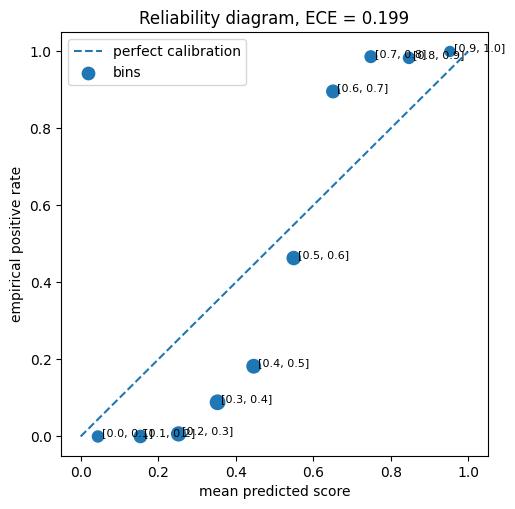

In [13]:
plt.figure(figsize=(5.5, 5.5))
plt.plot([0, 1], [0, 1], linestyle="--", label="perfect calibration")
plt.scatter(cal["mean_score"], cal["empirical_accuracy"], s=40 + 400 * cal["weight"], label="bins")
for _, row in cal.iterrows():
    plt.text(row["mean_score"] + 0.01, row["empirical_accuracy"], row["bin"], fontsize=8)
plt.xlabel("mean predicted score")
plt.ylabel("empirical positive rate")
plt.title(f"Reliability diagram, ECE = {ece:.3f}")
plt.legend()
plt.show()

In [14]:
# Group-wise calibration can reveal hidden differences.
cal_rows = []
for group, sub in scores.groupby("group"):
    _, e = calibration_table(sub["y"], sub["score"], bins=8)
    cal_rows.append({"group": group, "ECE": e, "mean_score": sub["score"].mean(), "base_rate": sub["y"].mean()})
pd.DataFrame(cal_rows)

,group,ECE,mean_score,base_rate
0,formal_helpdesk,0.182912,0.461916,0.410
1,informal_forum,0.203122,0.431015,0.298


## 7. Distribution shift and weighted risk

Let $P$ be the training/evaluation distribution and $Q$ be the deployment distribution. Distribution shift means

$$
P(X,A,Y) \ne Q(X,A,Y).
$$

Even if a test set is well labeled, it estimates risk for the distribution that generated it. If deployment has a different mixture of text sources, the unweighted test risk can be misleading.

Under a simple covariate-shift correction, if source proportions change and we know the ratio

$$
w(a)=\frac{Q(A=a)}{P(A=a)},
$$

then a weighted average can estimate deployment risk better than an unweighted average.

In [15]:
# Suppose the evaluation set is 50% formal and 50% informal,
# but deployment is expected to be 25% formal and 75% informal.
train_mix = pd.Series({"formal_helpdesk": 0.50, "informal_forum": 0.50})
deploy_mix = pd.Series({"formal_helpdesk": 0.25, "informal_forum": 0.75})

threshold = 0.50
scores = scores.copy()
scores["yhat"] = (scores["score"] >= threshold).astype(int)
scores["loss"] = (scores["yhat"] != scores["y"]).astype(float)
scores["source_weight"] = scores["group"].map(lambda g: deploy_mix[g] / train_mix[g])

unweighted_error = scores["loss"].mean()
weighted_error = np.average(scores["loss"], weights=scores["source_weight"])
by_group_error = scores.groupby("group")["loss"].mean()

print("Error by group:")
display(by_group_error.to_frame("error_rate"))
print("Unweighted evaluation error:", round(unweighted_error, 4))
print("Deployment-mixture weighted error:", round(weighted_error, 4))

Error by group:


,error_rate
group,
formal_helpdesk,0.098
informal_forum,0.142


Unweighted evaluation error: 0.12
Deployment-mixture weighted error: 0.131


### Exercise pause

Change the deployment mixture to $90\%$ `formal_helpdesk` and $10\%$ `informal_forum`. Does the weighted error increase or decrease? Why?

## 8. Embedding association audit

Embedding spaces can encode associations. For target sets $X,Y$ and attribute sets $A,B$, define

$$
s(w,A,B)=\frac{1}{|A|}\sum_{a\in A}\cos(e_w,e_a)
-
\frac{1}{|B|}\sum_{b\in B}\cos(e_w,e_b).
$$

A positive value means word $w$ is closer to set $A$ than to set $B$ in the embedding geometry.

The following example is artificial. It is for understanding the computation, not for making real-world claims.

In [16]:
emb = {
    "nurse": np.array([0.12, 0.85]),
    "teacher": np.array([0.25, 0.75]),
    "engineer": np.array([0.82, 0.12]),
    "programmer": np.array([0.78, 0.22]),
    "care": np.array([0.05, 1.00]),
    "family": np.array([0.10, 0.95]),
    "logic": np.array([1.00, 0.03]),
    "machine": np.array([0.96, 0.12]),
}

def cosine(u, v):
    u = np.asarray(u, dtype=float)
    v = np.asarray(v, dtype=float)
    return float(u @ v / (np.linalg.norm(u) * np.linalg.norm(v)))

def association(word, A, B, embeddings):
    return np.mean([cosine(embeddings[word], embeddings[a]) for a in A]) - np.mean([cosine(embeddings[word], embeddings[b]) for b in B])

X = ["nurse", "teacher"]
Y = ["engineer", "programmer"]
A = ["care", "family"]
B = ["logic", "machine"]

assoc_df = pd.DataFrame({
    "word": X + Y,
    "association_to_A_minus_B": [association(w, A, B, emb) for w in X + Y]
})
assoc_df

,word,association_to_A_minus_B
0,nurse,0.782177
1,teacher,0.581939
2,engineer,-0.775762
3,programmer,-0.634469


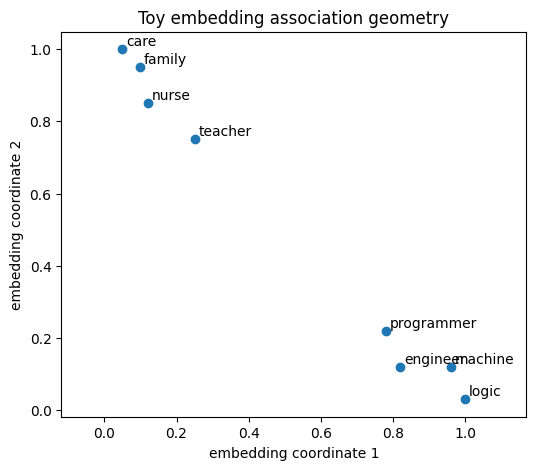

In [17]:
points = pd.DataFrame([
    {"word": w, "x": v[0], "y": v[1], "set": ("target" if w in X + Y else "attribute")}
    for w, v in emb.items()
])

plt.figure(figsize=(6, 5))
plt.scatter(points["x"], points["y"])
for _, row in points.iterrows():
    plt.text(row["x"] + 0.01, row["y"] + 0.01, row["word"])
plt.xlabel("embedding coordinate 1")
plt.ylabel("embedding coordinate 2")
plt.title("Toy embedding association geometry")
plt.axis("equal")
plt.show()

### Projection-based correction

A linear projection can remove one chosen direction. If $b$ is a unit direction, then

$$
\Pi_{b^\perp}(v)=v-(v^Tb)b.
$$

This operation is mathematically clear, but it is not a complete solution. Bias may be nonlinear, contextual, or encoded in many directions.

In [18]:
mean_A = np.mean([emb[a] for a in A], axis=0)
mean_B = np.mean([emb[b] for b in B], axis=0)
bias_direction = mean_A - mean_B
bias_direction = bias_direction / np.linalg.norm(bias_direction)


def remove_direction(v, b):
    return v - (v @ b) * b

emb_projected = {w: remove_direction(v, bias_direction) for w, v in emb.items()}

comparison = pd.DataFrame({
    "word": X + Y,
    "before": [association(w, A, B, emb) for w in X + Y],
    "after_projection": [association(w, A, B, emb_projected) for w in X + Y],
})
comparison

,word,before,after_projection
0,nurse,0.782177,0.000000e+00
1,teacher,0.581939,0.000000e+00
2,engineer,-0.775762,1.110223e-16
3,programmer,-0.634469,0.000000e+00


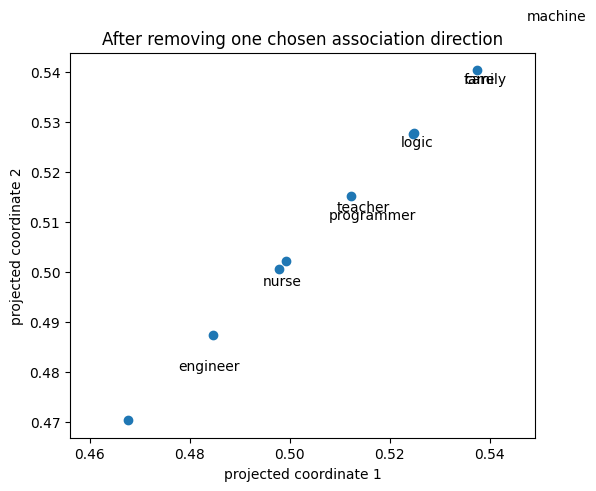

In [19]:
proj_points = pd.DataFrame([
    {"word": w, "x": v[0], "y": v[1]}
    for w, v in emb_projected.items()
])

plt.figure(figsize=(6, 5))
plt.scatter(proj_points["x"], proj_points["y"])
for _, row in proj_points.iterrows():
    plt.text(row["x"] + 0.01, row["y"] + 0.01, row["word"])
plt.xlabel("projected coordinate 1")
plt.ylabel("projected coordinate 2")
plt.title("After removing one chosen association direction")
plt.axis("equal")
plt.show()

## 9. Selective prediction and abstention

A responsible NLP system may need to say “I am not confident enough; send this to a person.” A selective classifier is

$$
g_\tau(x)=
\begin{cases}
\widehat{y}(x), & c(x)\ge \tau,\\
\bot, & c(x)<\tau,
\end{cases}
$$

where $c(x)$ is confidence and $\bot$ means abstain.

Two quantities matter:

$$
\operatorname{coverage}(\tau)=P(c(X)\ge \tau),
$$

$$
\operatorname{selective\ risk}(\tau)=E[L(\widehat{Y},Y)\mid c(X)\ge \tau].
$$

Higher confidence thresholds usually lower risk among answered cases but also lower coverage.

In [20]:
s = scores["score"].to_numpy()
y = scores["y"].to_numpy()
yhat = (s >= 0.50).astype(int)
confidence = np.maximum(s, 1 - s)
loss = (yhat != y).astype(float)

selective_rows = []
for tau in np.linspace(0.50, 0.95, 10):
    keep = confidence >= tau
    selective_rows.append({
        "confidence_threshold": tau,
        "coverage": keep.mean(),
        "selective_error": loss[keep].mean() if keep.sum() > 0 else np.nan,
        "abstention_rate": 1 - keep.mean(),
        "answered_cases": int(keep.sum()),
    })

selective = pd.DataFrame(selective_rows)
selective

,confidence_threshold,coverage,selective_error,abstention_rate,answered_cases
0,0.50,1.000,0.120000,0.000,1000
1,0.55,0.876,0.071918,0.124,876
2,0.60,0.740,0.039189,0.260,740
3,0.65,0.597,0.018425,0.403,597
4,0.70,0.465,0.006452,0.535,465
5,0.75,0.344,0.005814,0.656,344
6,0.80,0.241,0.004149,0.759,241
7,0.85,0.162,0.000000,0.838,162
8,0.90,0.087,0.000000,0.913,87
9,0.95,0.046,0.000000,0.954,46


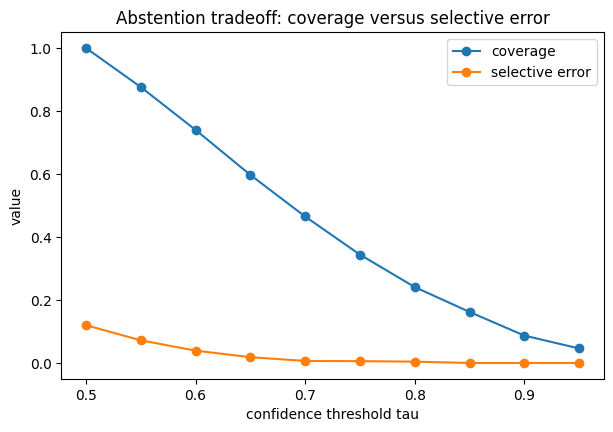

In [21]:
plt.figure(figsize=(7, 4.5))
plt.plot(selective["confidence_threshold"], selective["coverage"], marker="o", label="coverage")
plt.plot(selective["confidence_threshold"], selective["selective_error"], marker="o", label="selective error")
plt.xlabel("confidence threshold tau")
plt.ylabel("value")
plt.title("Abstention tradeoff: coverage versus selective error")
plt.legend()
plt.show()

### Responsible deployment note

Abstention is useful only if there is a safe fallback: human review, retrieval of source documents, refusal, escalation, or a slower verification procedure. Abstention without a fallback is not responsibility.

## 10. Privacy: randomized response as a simple differential privacy example

A randomized mechanism $M$ is $\epsilon$-differentially private if changing one person's data cannot change output probabilities too much:

$$
P(M(D)\in S) \le e^\epsilon P(M(D')\in S).
$$

For randomized response with a private binary answer $Y$, release the truth with probability $p$ and flip it with probability $1-p$. The privacy parameter is

$$
\epsilon=\log\frac{p}{1-p}.
$$

As $p$ moves toward $1/2$, privacy becomes stronger but the answer becomes less useful. As $p$ moves toward $1$, the answer becomes more accurate but less private.

In [22]:
ps = np.array([0.51, 0.55, 0.60, 0.70, 0.80, 0.90, 0.95])
eps = np.log(ps / (1 - ps))
privacy_table = pd.DataFrame({
    "truth_probability_p": ps,
    "epsilon": eps,
    "flip_probability": 1 - ps,
})
privacy_table

,truth_probability_p,epsilon,flip_probability
0,0.51,0.040005,0.49
1,0.55,0.200671,0.45
2,0.60,0.405465,0.40
3,0.70,0.847298,0.30
4,0.80,1.386294,0.20
5,0.90,2.197225,0.10
6,0.95,2.944439,0.05


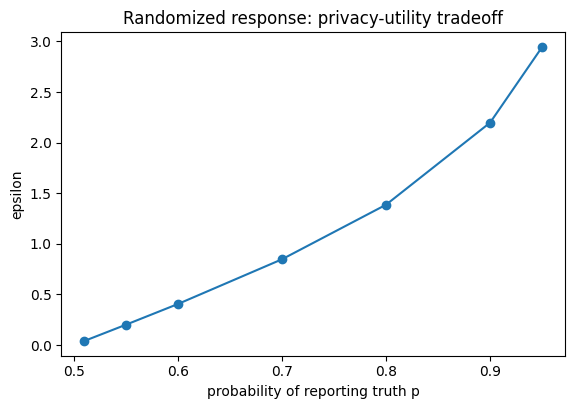

In [23]:
plt.figure(figsize=(6.5, 4.2))
plt.plot(privacy_table["truth_probability_p"], privacy_table["epsilon"], marker="o")
plt.xlabel("probability of reporting truth p")
plt.ylabel("epsilon")
plt.title("Randomized response: privacy-utility tradeoff")
plt.show()

## 11. RAG and factuality responsibility checklist

For a retrieval-augmented generation system, separate two sources of error:

$$
D_1,\ldots,D_k \sim r_\eta(d\mid x),
\qquad
Z \sim p_\theta(z\mid x,D_1,\ldots,D_k).
$$

The retriever can fail, and the generator can fail. A clear audit separates these questions:

| Component | Audit question | Possible metric |
|---|---|---|
| Retriever | Did it retrieve enough relevant evidence? | recall@k, context precision, source coverage |
| Generator | Did it use the evidence faithfully? | citation support rate, contradiction rate |
| Final answer | Is the answer useful and honest? | human rubric, factuality score, uncertainty statement |
| Deployment | What happens when evidence is missing? | refusal rate, escalation rate, unsupported-answer rate |

This table is not code-heavy, but it is mathematically important: a fluent answer is not the same thing as a supported answer.

In [24]:
rag_audit = pd.DataFrame({
    "question": [
        "Were relevant documents retrieved?",
        "Were retrieved documents recent enough?",
        "Does every factual claim have support?",
        "Does the answer mention uncertainty or missing evidence?",
        "Is there a safe fallback when evidence is insufficient?",
    ],
    "score_0_to_2": [2, 1, 1, 0, 2],
    "notes": [
        "Top-3 contains two relevant documents.",
        "One source is older than the policy update date.",
        "One sentence summarizes unsupported information.",
        "The answer sounds more certain than the evidence permits.",
        "Escalation to human review is defined.",
    ]
})
rag_audit["normalized_score"] = rag_audit["score_0_to_2"] / 2
rag_audit

,question,score_0_to_2,notes,normalized_score
0,Were relevant documents retrieved?,2,Top-3 contains two relevant documents.,1.0
1,Were retrieved documents recent enough?,1,One source is older than the policy update date.,0.5
2,Does every factual claim have support?,1,One sentence summarizes unsupported information.,0.5
3,Does the answer mention uncertainty or missing...,0,The answer sounds more certain than the eviden...,0.0
4,Is there a safe fallback when evidence is insu...,2,Escalation to human review is defined.,1.0


In [25]:
print("Mean audit score:", round(rag_audit["normalized_score"].mean(), 3))
print("Lowest-scoring audit items:")
display(rag_audit.sort_values("normalized_score").head(2))

Mean audit score: 0.6
Lowest-scoring audit items:


,question,score_0_to_2,notes,normalized_score
3,Does the answer mention uncertainty or missing...,0,The answer sounds more certain than the eviden...,0.0
1,Were retrieved documents recent enough?,1,One source is older than the policy update date.,0.5


## 12. Final audit report template

Use the following template when auditing an NLP system.

### A. Task definition

- What is $X$?
- What is $Y$?
- What is the decision rule $d(x)$?
- What does a false positive mean?
- What does a false negative mean?

### B. Population and deployment

- What distribution generated the training data?
- What distribution generated the test data?
- What distribution will use the deployed model?
- What kinds of distribution shift are plausible?

### C. Metrics and uncertainty

- Overall accuracy or loss.
- Group-wise confusion matrices.
- TPR, FPR, PPV, selection rate.
- Calibration and ECE.
- Bootstrap intervals or other uncertainty estimates.

### D. Safety and responsibility

- Is abstention available?
- What happens when confidence is low?
- Is there human review?
- Are source documents or citations required?
- Are privacy risks addressed?

### E. Recommendation

- Deploy as-is.
- Deploy with restrictions.
- Redesign and re-evaluate.
- Do not deploy.

State the mathematical evidence that supports your recommendation.

## 13. Exercises

### Exercise 1 — Manual group metrics

Using the output of `group_confusion_metrics(scores, threshold=0.50)`, manually verify the TPR and FPR for each group.

### Exercise 2 — Equal opportunity threshold

Find the threshold that gives the smallest TPR gap. What is the resulting overall accuracy? Compare it with the accuracy-maximizing threshold.

### Exercise 3 — Calibration by group

Compute calibration tables separately for both groups. Which group has larger ECE? Does this match your intuition from the score distributions?

### Exercise 4 — Distribution shift

Change the deployment mixture to:

- $10\%$ `formal_helpdesk`, $90\%$ `informal_forum`;
- $90\%$ `formal_helpdesk`, $10\%$ `informal_forum`.

How does the weighted error change?

### Exercise 5 — Embedding projection

Change the toy embedding coordinates. Can you create an example where projection reduces one association score but changes unrelated cosine similarities substantially?

### Exercise 6 — Selective prediction

Choose a confidence threshold $\tau$ that gives at least $80\%$ coverage. What is the selective error? What cases are abstained on most often?

### Exercise 7 — Privacy

For randomized response, compute $p$ from a chosen $\epsilon$:

$$
p = \frac{e^\epsilon}{1+e^\epsilon}.
$$

Try $\epsilon=0.5,1,2,4$ and interpret the results.

## 14. Mini-project — Mathematical audit of a small NLP classifier

Choose a small text classification task. You may use the synthetic dataset in this lab or create your own small dataset.

Your final report should include:

1. a precise definition of $X$, $Y$, $A$, $S$, and $\widehat{Y}$;
2. a model or scoring rule;
3. group-wise confusion matrices;
4. at least two fairness metrics;
5. threshold-scan analysis;
6. calibration analysis;
7. uncertainty analysis;
8. a distribution-shift scenario;
9. an abstention or escalation rule;
10. a final recommendation about deployment.

The goal is not to build the most accurate model. The goal is to practice mathematically responsible evaluation.

## 15. AI-assisted learning prompts

Use an AI assistant carefully. Treat it as a brainstorming partner, not as evidence.

Try these prompts:

1. “Here is my NLP task definition. What assumptions are missing?”
2. “Given my confusion matrices, which fairness criteria could be relevant and why?”
3. “What distribution shifts are plausible for this deployment setting?”
4. “What evidence would be needed before deploying this model?”
5. “Critique my audit report for missing uncertainty, privacy, or factuality issues.”

Then verify every suggestion using definitions, data, and transparent calculations.

## 16. Lab summary

This lab connected ethics and responsibility to concrete mathematical objects:

- $P(X,A,Y)$ describes the population and auditing context.
- A score $S$ becomes a decision only after a threshold or deployment rule is chosen.
- Group fairness metrics are conditional probabilities.
- Different fairness metrics can conflict.
- Calibration measures whether scores behave like probabilities.
- Bootstrap intervals remind us that subgroup metrics have uncertainty.
- Distribution shift changes what a test-set score means.
- Embedding association can be studied geometrically, but simple projection is not a complete fix.
- Abstention reduces risk only when paired with a meaningful fallback.
- Privacy and factuality require separate mathematical treatment.

Responsible NLP is not a final checklist after modeling. It starts when we choose the data, labels, representations, objective function, metrics, and deployment rules.